In [ ]:
# Import untuk menghubungkan Google Drive
from google.colab import drive

# Import Library Data Handling
import pandas as pd
import numpy as np

# Import Library Preprocessing dan Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Import Library Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Import Library Evaluasi
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [ ]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Definisikan path ke file Anda
file_path = '/content/drive/MyDrive/AOLAI/diabetes_012_health_indicators_BRFSS2015.csv'

# 3. Baca data ke dalam DataFrame pandas
df = pd.read_csv(file_path)

# Tampilkan 5 baris pertama untuk memastikan data berhasil dimuat
print(df.head())

Mounted at /content/drive
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0 

## Data Understanding

In [ ]:
# --- 1. Jumlah Baris dan Kolom ---
print("--- 1. Dimensi Dataset ---")
jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]
print(f"Jumlah Baris (Survei Respons): {jumlah_baris:,}")
print(f"Jumlah Kolom (Fitur + Target): {jumlah_kolom}")
print("-" * 30)

--- 1. Dimensi Dataset ---
Jumlah Baris (Survei Respons): 253,680
Jumlah Kolom (Fitur + Target): 22
------------------------------


In [ ]:
# --- 2. Informasi Kolom dan Tipe Data ---
print("--- 2. Info Kolom dan Tipe Data ---")
print(df.info())
print("-" * 30)

--- 2. Info Kolom dan Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth         

In [ ]:
# --- 3. Persebaran Nilai (Unik dan Deskriptif) ---

# Tampilkan nilai unik untuk kolom bertipe kategori/ordinal
categorical_cols = ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
print("--- 3.1. Persebaran Nilai Kategori/Ordinal ---")
for col in categorical_cols:
    print(f"\n{col} (Nilai Unik):")
    # Hitung nilai unik dan persentase, urutkan berdasarkan index
    value_counts = df[col].value_counts().sort_index()
    percentage = (df[col].value_counts(normalize=True) * 100).sort_index().round(2)

    # Gabungkan menjadi satu DataFrame
    summary = pd.DataFrame({'Count': value_counts, 'Percentage': percentage.astype(str) + ' %'})

    # Sesuaikan label untuk Diabetes_012 agar mudah dipahami
    if col == 'Diabetes_012':
        summary.index = ['0: No Diabetes/Pregnancy', '1: Prediabetes', '2: Diabetes']

    print(summary)

print("\n--- 3.2. Statistik Deskriptif (Fitur Numerik) ---")
# Menampilkan statistik deskriptif untuk fitur numerik
print(df[['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']].describe().round(2))
print("-" * 30)

--- 3.1. Persebaran Nilai Kategori/Ordinal ---

Diabetes_012 (Nilai Unik):
                           Count Percentage
0: No Diabetes/Pregnancy  213703    84.24 %
1: Prediabetes              4631     1.83 %
2: Diabetes                35346    13.93 %

HighBP (Nilai Unik):
         Count Percentage
HighBP                   
0.0     144851     57.1 %
1.0     108829     42.9 %

HighChol (Nilai Unik):
           Count Percentage
HighChol                   
0.0       146089    57.59 %
1.0       107591    42.41 %

CholCheck (Nilai Unik):
            Count Percentage
CholCheck                   
0.0          9470     3.73 %
1.0        244210    96.27 %

Smoker (Nilai Unik):
         Count Percentage
Smoker                   
0.0     141257    55.68 %
1.0     112423    44.32 %

Stroke (Nilai Unik):
         Count Percentage
Stroke                   
0.0     243388    95.94 %
1.0      10292     4.06 %

HeartDiseaseorAttack (Nilai Unik):
                       Count Percentage
HeartDiseaseorAtta

--- Pembuatan Histogram Fitur Non-Biner Dimulai ---

--- Nilai Skewness Fitur Non-Biner ---
MentHlth        2.721148
PhysHlth        2.207395
BMI             2.122004
Diabetes_012    1.976390
GenHlth         0.422867
Age            -0.359903
Education      -0.777255
Income         -0.891345
dtype: float64
----------------------------------------


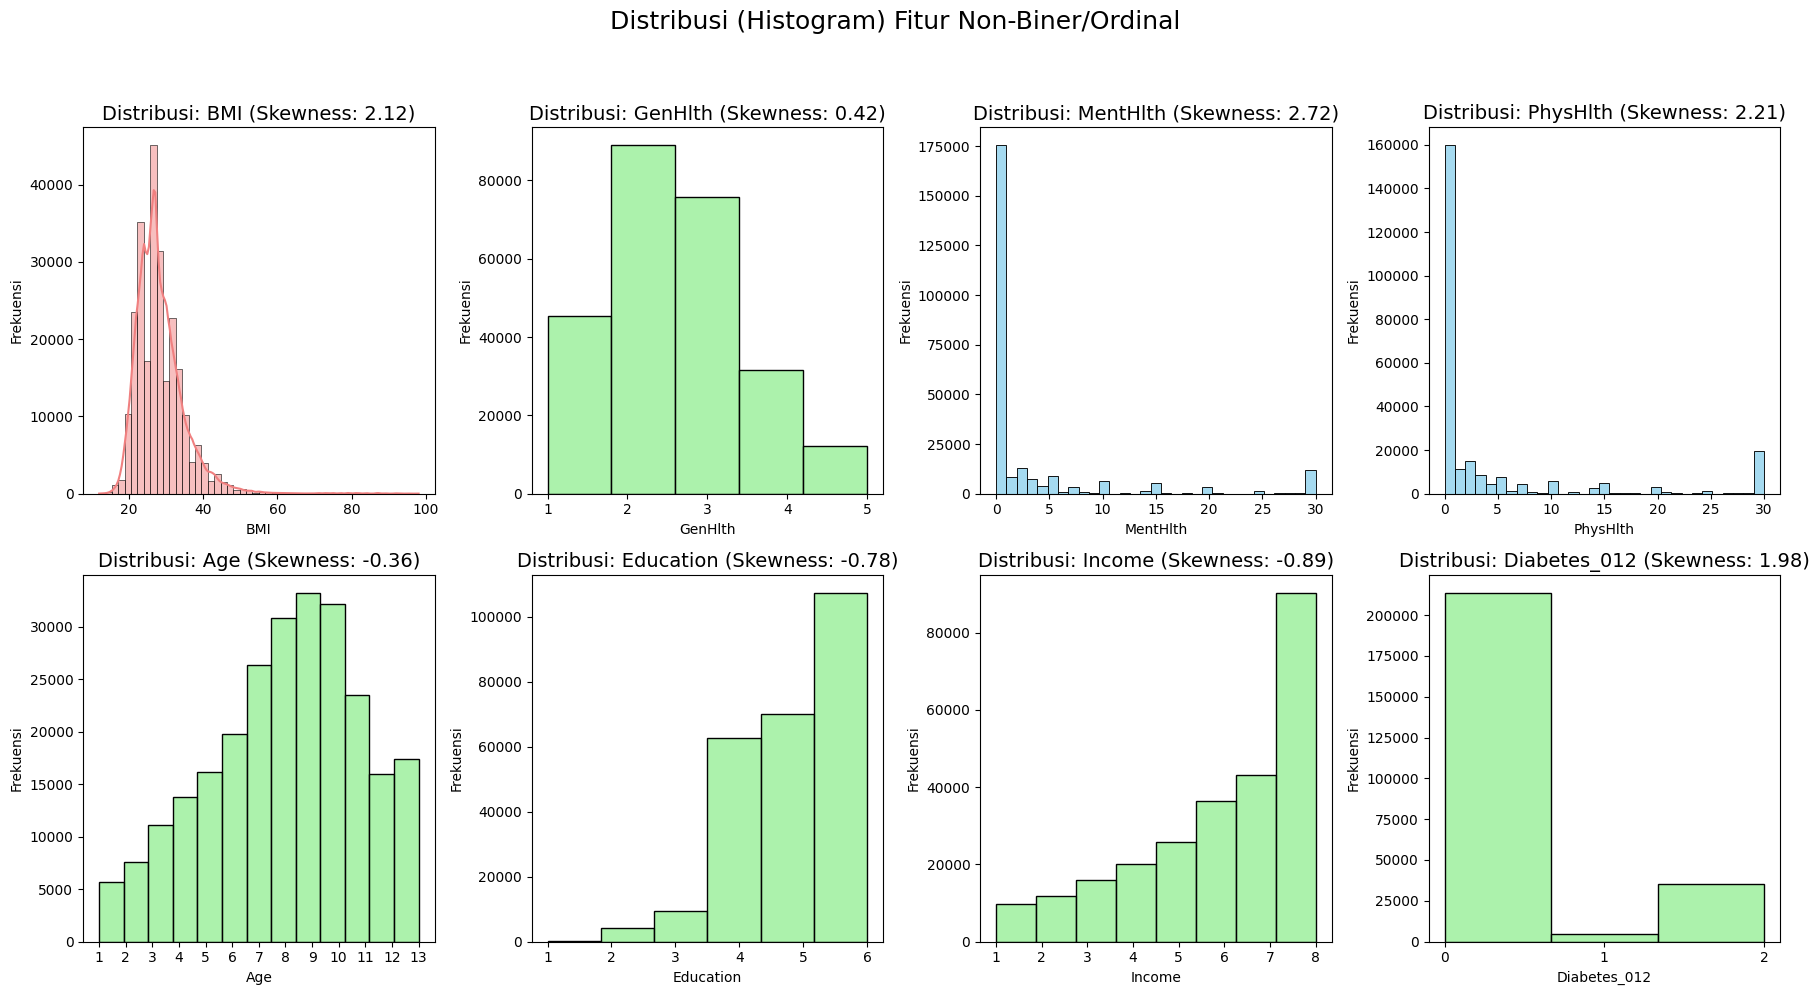

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


print("--- Pembuatan Histogram Fitur Non-Biner Dimulai ---")

# Identifikasi kolom yang bukan hanya biner (lebih dari 2 nilai unik)
# Kita juga mengecualikan kolom target
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

all_cols = df.columns.tolist()
target_col = 'Diabetes_012'

# Fitur yang akan diplot (Non-Biner/Kontinu/Ordinal)
# Ini termasuk BMI, GenHlth, MentHlth, PhysHlth, Age, Education, Income, dan target
feature_cols = [col for col in all_cols if col not in binary_cols and col != target_col]
feature_cols.append(target_col) # Tambahkan target untuk melihat distribusinya

# --- 1. Hitung dan Tampilkan Skewness ---
print("\n--- Nilai Skewness Fitur Non-Biner ---")
# Hitung skewness hanya untuk fitur yang akan diplot
skewness_results = df[feature_cols].skew().sort_values(ascending=False)
print(skewness_results)
print("-" * 40)


# --- Membuat Histogram untuk Setiap Fitur Non-Biner ---
num_features = len(feature_cols)
# Atur tata letak subplot (misalnya 4 kolom)
n_cols = 4
n_rows = int(np.ceil(num_features / n_cols))

plt.figure(figsize=(18, 5 * n_rows))
plt.suptitle('Distribusi (Histogram) Fitur Non-Biner/Ordinal', fontsize=18, y=1.02)

for i, col in enumerate(feature_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    # Dapatkan nilai skewness untuk digunakan di judul plot
    skew_val = skewness_results[col]

    # Atur bins secara otomatis
    # Untuk fitur seperti MentHlth (0-30), bins bisa disesuaikan.
    if col in ['MentHlth', 'PhysHlth']:
        sns.histplot(df[col], bins=31, kde=False, color='skyblue', edgecolor='black')
        plt.xticks(range(0, 31, 5)) # Tampilkan label setiap 5 hari
    elif col == 'BMI':
        sns.histplot(df[col], bins=50, kde=True, color='lightcoral', edgecolor='black')
    else:
        # Untuk fitur ordinal (Age, Education, Income, GenHlth) dan Target
        sns.histplot(df[col], bins=len(df[col].unique()), kde=False, color='lightgreen', edgecolor='black')
        plt.xticks(df[col].unique())

    # Tampilkan nilai skewness di judul plot
    plt.title(f'Distribusi: {col} (Skewness: {skew_val:.2f})', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Sesuaikan layout agar tidak tumpang tindih
plt.show()

In [ ]:
# --- 4. Cek Missing Value ---
print("--- 4. Cek Missing Values ---")
print(df.isnull().sum())
print("-" * 30)

--- 4. Cek Missing Values ---
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
------------------------------


--- 1. Korelasi Pearson dengan Diabetes_012 ---
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Fruits                 -0.042192
HvyAlcoholConsump      -0.057882
Veggies                -0.058972
PhysActivity           -0.121947
Education              -0.130517
Income                 -0.171483
Name: Diabetes_012, dtype: float64
--------------------------------------------------


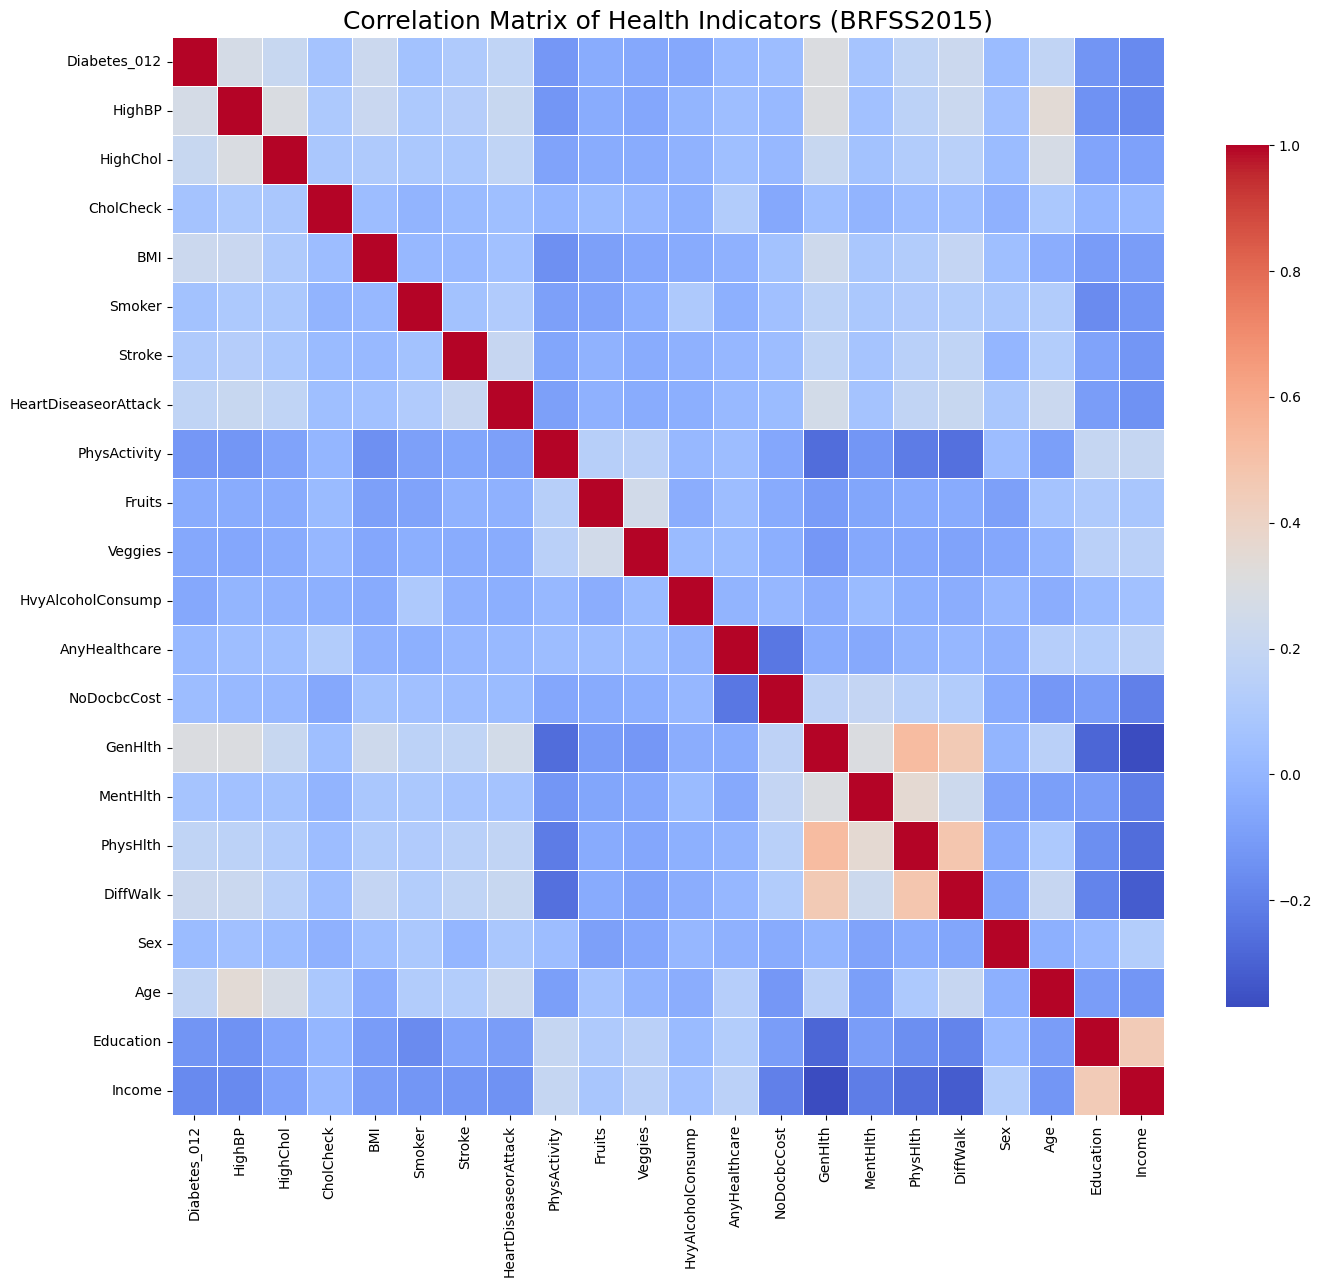

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan kita menggunakan DataFrame 'df' sebelum di-scale
# Kita akan menggunakan korelasi Pearson
correlation_matrix = df.corr(method='pearson')

# --- 1. Korelasi Fitur vs. Target (Diabetes_012) ---
print("--- 1. Korelasi Pearson dengan Diabetes_012 ---")

# Ambil baris korelasi target, urutkan dari yang paling kuat
target_corr = correlation_matrix['Diabetes_012'].sort_values(ascending=False)

# Hilangkan korelasi dengan dirinya sendiri (yang bernilai 1)
target_corr = target_corr.drop('Diabetes_012')

print(target_corr)
print("-" * 50)


# --- 2. Visualisasi Full Correlation Matrix (Heatmap) ---
plt.figure(figsize=(16, 14))
# Gunakan 'viridis' atau 'coolwarm' untuk visualisasi yang baik
sns.heatmap(
    correlation_matrix,
    annot=False,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar_kws={'shrink': .8}
)
plt.title('Correlation Matrix of Health Indicators (BRFSS2015)', fontsize=18)
plt.show()
#

## Data Preprocessing

In [ ]:
# --- 1. Pemisahan Fitur (X) dan Target (y) ---
X = df.drop('Diabetes_012', axis=1) # Semua kolom kecuali target
y = df['Diabetes_012']

In [ ]:
# --- 2. Target Encoding (One-Hot Encoding) ---
y_encoded = to_categorical(y)
num_classes = y_encoded.shape[1]
print(f"Target ter-encode menjadi {num_classes} kolom.")

Target ter-encode menjadi 3 kolom.


In [ ]:
# --- 3. Split Data: Training dan Testing ---
# Kita gunakan 80% untuk training dan 20% untuk testing
# Stratify=y memastikan proporsi kelas (imbalance) dipertahankan di set training dan testing
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Ukuran Data Training (X): {X_train.shape}")
print(f"Ukuran Data Testing (X): {X_test.shape}")

# Kita juga simpan y_train/y_test yang belum di-encode untuk menghitung Class Weights
_, _, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Ukuran Data Training (X): (202944, 21)
Ukuran Data Testing (X): (50736, 21)


In [ ]:
# --- 4. Feature Scaling (Standarisasi) ---

# Tentukan kolom yang akan di-scale
# Kolom yang sudah biner (0 atau 1) tidak perlu di-scale (HighBP, HighChol, etc.)
# Kita fokus pada BMI, GenHlth, MentHlth, PhysHlth, Age, Education, Income
scale_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

# Inisialisasi Scaler
scaler = StandardScaler()

# Lakukan fit pada data training, lalu transform data training dan testing
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print("\nFitur telah berhasil di-Standarisasi (Scaled).")
print(X_train[scale_cols].head()) # Cek hasil scaling


Fitur telah berhasil di-Standarisasi (Scaled).
             BMI   GenHlth  MentHlth  PhysHlth       Age  Education    Income
185494 -0.512552 -0.477655 -0.429290 -0.485961  0.642861  -1.064902 -0.990652
217030  1.301115 -1.414347 -0.429290 -0.485961 -2.302154  -0.050799 -0.507986
641     0.998837 -0.477655 -0.429290 -0.485961  0.970085  -0.050799 -1.473318
217863 -0.210274 -0.477655 -0.429290  0.088138 -1.647706  -1.064902 -0.025320
53677  -0.059135  0.459036 -0.023967 -0.485961  0.315637  -1.064902 -0.990652


In [ ]:
# --- 5. Menghitung Class Weights (Mengatasi Imbalance) ---

# Hitung bobot kelas menggunakan frekuensi kebalikan (inverse frequency)
# Ini adalah kunci untuk memastikan model memperhatikan kelas Prediabetes (1) dan Diabetes (2)
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Konversi array weights ke dictionary, yang dibutuhkan oleh Keras
class_weights = dict(enumerate(weights))

print("\n--- Class Weights (Untuk Imbalance) ---")
print(f"Kelas 0 (No Diabetes): {class_weights.get(0):.4f}")
print(f"Kelas 1 (Prediabetes): {class_weights.get(1):.4f}")
print(f"Kelas 2 (Diabetes): {class_weights.get(2):.4f}")


--- Class Weights (Untuk Imbalance) ---
Kelas 0 (No Diabetes): 0.3957
Kelas 1 (Prediabetes): 18.2586
Kelas 2 (Diabetes): 2.3923


##Modeling

In [ ]:
input_dim = X_train.shape[1]

# --- 1. Membangun Model MLP ---
model = Sequential([
    # Lapisan Input & Lapisan Tersembunyi Pertama
    # Neuron 128, Aktivasi ReLU
    Dense(128, activation='relu', input_shape=(input_dim,)),
    # Dropout untuk mencegah overfitting (mematikan 30% neuron secara acak)
    Dropout(0.3),

    # Lapisan Tersembunyi Kedua
    # Neuron 64, Aktivasi ReLU
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Lapisan Tersembunyi Ketiga
    # Neuron 32, Aktivasi ReLU
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Lapisan Output
    # Neuron 3 (sesuai jumlah kelas), Aktivasi Softmax untuk probabilitas multi-kelas
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# --- 2. Kompilasi Model ---
# Optimizer: Adam (standar yang bagus)
# Loss: Categorical Crossentropy (untuk klasifikasi multi-kelas dengan One-Hot Encoding)
# Metrics: Focus pada Recall dan F1-Score karena ada imbalance
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.F1Score(name='f1_score')]
)

# Tampilkan ringkasan arsitektur model
print("--- Arsitektur Model MLP ---")
model.summary()
print("-" * 35)

--- Arsitektur Model MLP ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 13,251 (51.76 KB)

 Non-trainable params: 0 (0.00 B)

-----------------------------------


In [ ]:
# --- 3. Pelatihan Model (Training) ---

# Tentukan parameter training
EPOCHS = 50
BATCH_SIZE = 512

print("\n--- Model Training Dimulai ---")

history = model.fit(
    X_train,
    y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)


--- Model Training Dimulai ---
Epoch 1/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5729 - f1_score: 0.3810 - loss: 1.0007 - recall: 0.3488 - val_accuracy: 0.5786 - val_f1_score: 0.4035 - val_loss: 0.8824 - val_recall: 0.3507
Epoch 2/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6021 - f1_score: 0.4072 - loss: 0.9716 - recall: 0.4036 - val_accuracy: 0.6218 - val_f1_score: 0.4150 - val_loss: 0.8600 - val_recall: 0.3956
Epoch 3/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6141 - f1_score: 0.4131 - loss: 0.9638 - recall: 0.4176 - val_accuracy: 0.5698 - val_f1_score: 0.4076 - val_loss: 0.8804 - val_recall: 0.3772
Epoch 4/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5990 - f1_score: 0.4114 - loss: 0.9614 - recall: 0.4172 - val_accuracy: 0.6028 - val_f1_score: 0.4160 - val_loss: 0.8500 - val_recall: 0.4099
Epoch 5/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6001 - f1_score: 0.4122 - loss: 0.9601 - recall: 0.4190 - val_accurac

## Evaluation

--- 1. Grafik Sejarah Pelatihan ---


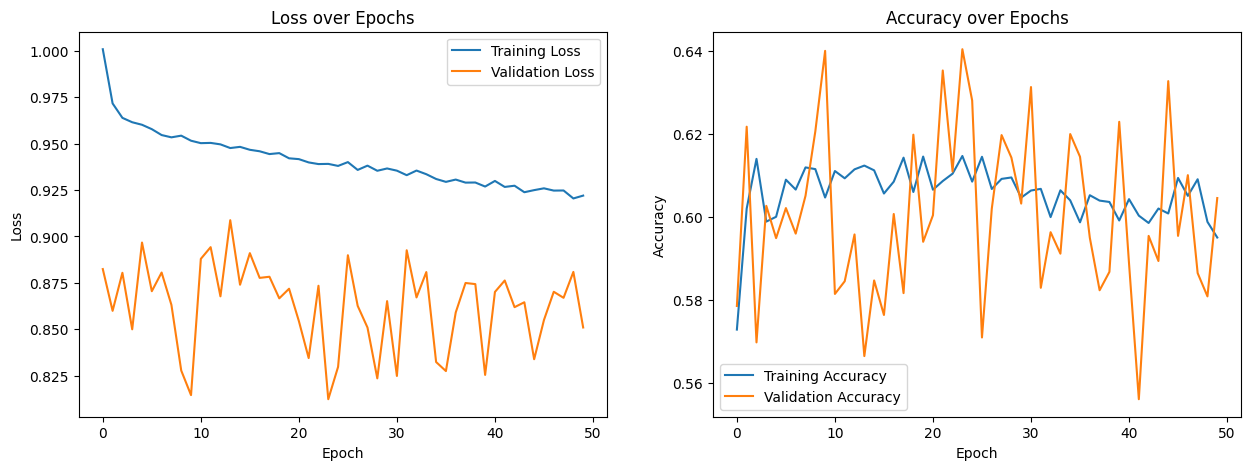

In [ ]:
# --- 1. Plot Metrik Pelatihan ---
print("--- 1. Grafik Sejarah Pelatihan ---")

# Fungsi untuk membuat plot
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Plot Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.show()

plot_training_history(history)

In [ ]:
# --- 2. Evaluasi pada Data Testing ---

# Melakukan prediksi pada data testing
y_pred_cat = model.predict(X_test)
# Mengubah hasil prediksi dari one-hot encoding kembali ke label kelas (0, 1, 2)
y_pred = np.argmax(y_pred_cat, axis=1)

# Mengubah y_test_cat (one-hot) kembali ke label kelas (0, 1, 2)
y_true = np.argmax(y_test_cat, axis=1)

# Hitung metrik F1-Score (penting untuk imbalance)
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print("\n--- 2.1. Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_true, y_pred, target_names=['0: No Diabetes', '1: Prediabetes', '2: Diabetes']))
print(f"F1-Score (Weighted): {weighted_f1:.4f}")
print("-" * 50)

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

--- 2.1. Laporan Klasifikasi (Classification Report) ---
                precision    recall  f1-score   support

0: No Diabetes       0.96      0.62      0.75     42741
1: Prediabetes       0.03      0.37      0.05       926
   2: Diabetes       0.35      0.55      0.43      7069

      accuracy                           0.60     50736
     macro avg       0.45      0.51      0.41     50736
  weighted avg       0.85      0.60      0.69     50736

F1-Score (Weighted): 0.6931
--------------------------------------------------



--- 3. Confusion Matrix ---


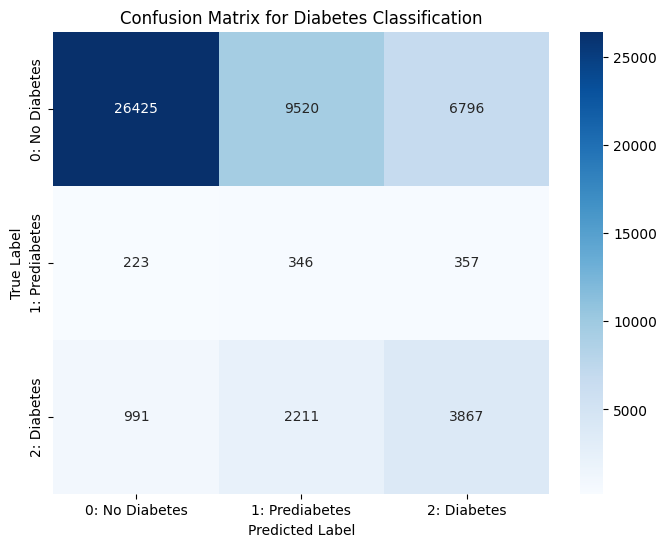

In [ ]:
# --- 3. Confusion Matrix ---
print("\n--- 3. Confusion Matrix ---")

cm = confusion_matrix(y_true, y_pred)
labels = ['0: No Diabetes', '1: Prediabetes', '2: Diabetes']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Diabetes Classification')
plt.show()
#

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


--- Model XGBoost Dibuat ---

--- Model XGBoost Training Dimulai ---
--- Model XGBoost Training Selesai ---

--- 3.1. Prediksi pada Data Testing ---

--- 3.2. Laporan Klasifikasi (Classification Report) XGBoost ---
                precision    recall  f1-score   support

0: No Diabetes       0.95      0.65      0.77     42741
1: Prediabetes       0.03      0.26      0.05       926
   2: Diabetes       0.34      0.64      0.44      7069

      accuracy                           0.64     50736
     macro avg       0.44      0.51      0.42     50736
  weighted avg       0.85      0.64      0.71     50736


--- 3.3. Confusion Matrix XGBoost ---


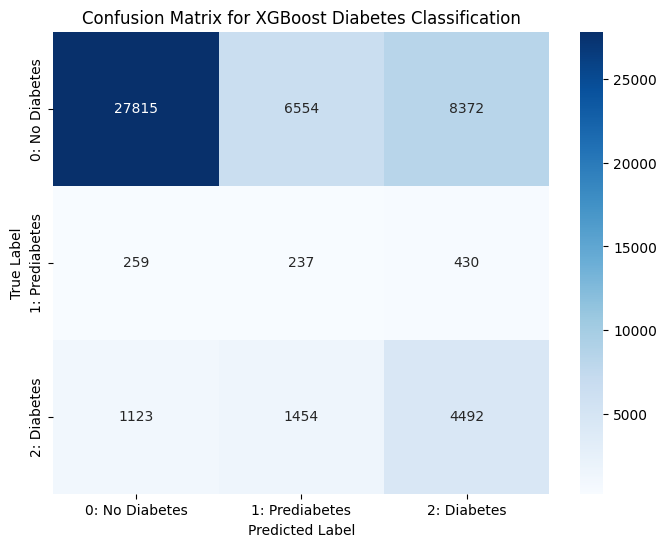

In [ ]:

# --- 1. Inisialisasi Model XGBoost ---


from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool



model_xgb = XGBClassifier(
    #objective='multi:softmax',
        n_estimators=2000,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='multi:softmax',
    eval_metric='auc',
    tree_method='hist',
    verbosity=0,
    enable_categorical=True
)

print("--- Model XGBoost Dibuat ---")

# --- 2. Pelatihan Model (Training) ---
print("\n--- Model XGBoost Training Dimulai ---")

# mapping class label to its weight
weights_map = {0: class_weights[0], 1: class_weights[1], 2: class_weights[2]}
# create a list of weights for each sample in y_train
sample_weights_array = np.array([weights_map[label] for label in y_train])

model_xgb.fit(X_train, y_train, sample_weight=sample_weights_array)

print("--- Model XGBoost Training Selesai ---")

# --- 3. Evaluasi pada Data Testing ---
print("\n--- 3.1. Prediksi pada Data Testing ---")
y_pred_xgb = model_xgb.predict(X_test)

print("\n--- 3.2. Laporan Klasifikasi (Classification Report) XGBoost ---")
print(classification_report(y_test, y_pred_xgb, target_names=['0: No Diabetes', '1: Prediabetes', '2: Diabetes']))

print("\n--- 3.3. Confusion Matrix XGBoost ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0: No Diabetes', '1: Prediabetes', '2: Diabetes'],
    yticklabels=['0: No Diabetes', '1: Prediabetes', '2: Diabetes']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost Diabetes Classification')
plt.show()

In [ ]:
print("\n--- 3.1. Prediksi pada Data Testing ---")
y_pred_xgb = model_xgb.predict(X_test)

from sklearn.metrics import f1_score
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(classification_report(y_test, y_pred_xgb, target_names=['0: No Diabetes', '1: Prediabetes', '2: Diabetes']))
print(f"F1-Score (Weighted Average): {weighted_f1_xgb:.4f}")


--- 3.1. Prediksi pada Data Testing ---
                precision    recall  f1-score   support

0: No Diabetes       0.95      0.65      0.77     42741
1: Prediabetes       0.03      0.26      0.05       926
   2: Diabetes       0.34      0.64      0.44      7069

      accuracy                           0.64     50736
     macro avg       0.44      0.51      0.42     50736
  weighted avg       0.85      0.64      0.71     50736

F1-Score (Weighted Average): 0.7139


In [ ]:
import pandas as pd
import numpy as np

# --- 1. DEFINISI FUNGSI PREDIKSI (YANG TADI HILANG/ERROR) ---
def prediksi_diabetes(input_data):

    new_df = pd.DataFrame([input_data])

    try:
        feature_order = X.columns
        new_df = new_df[feature_order]
    except NameError:
        print("Error: Data training (X) tidak ditemukan. Pastikan proses training sudah dijalankan.")
        return

    scale_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
    new_df[scale_cols] = scaler.transform(new_df[scale_cols])

    # Lakukan Prediksi (Menggunakan model XGBoost yang sudah dilatih)
    try:
        prediction = model_xgb.predict(new_df)[0]
    except NameError:
        # Fallback jika model_xgb belum ada, coba pakai model Neural Network
        try:
            pred_prob = model.predict(new_df)
            prediction = np.argmax(pred_prob, axis=1)[0]
        except:
            print("Error: Model tidak ditemukan. Harap jalankan training model dulu.")
            return

    # Mapping hasil angka ke label teks
    label_map = {
        0: 'TIDAK ADA DIABETES (SEHAT) ✅',
        1: 'PREDIABETES (WASPADA) ⚠️',
        2: 'DIABETES ❗'
    }

    result = label_map.get(prediction, "Unknown")

    print("\n" + "="*50)
    print(f"  HASIL PREDIKSI: {result}")
    print("="*50)
    return result

# --- 2. DEFINISI FUNGSI INPUT INTERAKTIF ---
def get_user_input(prompt, type_func=int, min_val=None, max_val=None):
    while True:
        try:
            raw = input(prompt)
            if not raw.strip(): return 0 # Default 0 jika kosong (opsional)
            val = type_func(raw)
            if min_val is not None and val < min_val:
                print(f"   ❌ Nilai min: {min_val}")
                continue
            if max_val is not None and val > max_val:
                print(f"   ❌ Nilai max: {max_val}")
                continue
            return val
        except ValueError:
            print("   ❌ Masukkan angka yang valid.")

def mulai_diagnosa_interaktif():
    print("\n" + "="*60)
    print("       DIAGNOSA DIABETES AI")
    print("="*60)

    data = {}

    print("\n[A. RIWAYAT KESEHATAN (0=Tidak, 1=Ya)]")
    data['HighBP'] = get_user_input(" 1. Tekanan darah tinggi? : ", int, 0, 1)
    data['HighChol'] = get_user_input(" 2. Kolesterol tinggi? : ", int, 0, 1)
    data['CholCheck'] = get_user_input(" 3. Cek kolesterol 5thn terakhir? : ", int, 0, 1)
    data['Smoker'] = get_user_input(" 4. Perokok (min 100 btg)? : ", int, 0, 1)
    data['Stroke'] = get_user_input(" 5. Pernah stroke? : ", int, 0, 1)
    data['HeartDiseaseorAttack'] = get_user_input(" 6. Sakit jantung/serangan? : ", int, 0, 1)
    data['PhysActivity'] = get_user_input(" 7. Olahraga rutin (30 hari)? : ", int, 0, 1)
    data['AnyHealthcare'] = get_user_input(" 8. Punya asuransi? : ", int, 0, 1)
    data['NoDocbcCost'] = get_user_input(" 9. Batal ke dokter krn biaya? : ", int, 0, 1)
    data['DiffWalk'] = get_user_input("10. Susah jalan/naik tangga? : ", int, 0, 1)

    print("\n[B. GAYA HIDUP]")
    print("Info BMI: 24.0 (Normal), 28.0 (Gemuk), 32.0 (Obesitas)")
    data['BMI'] = get_user_input("11. BMI (angka desimal, cth 24.5) : ", float, 10, 100)
    data['Fruits'] = get_user_input("12. Makan buah tiap hari? (0/1) : ", int, 0, 1)
    data['Veggies'] = get_user_input("13. Makan sayur tiap hari? (0/1) : ", int, 0, 1)
    data['HvyAlcoholConsump'] = get_user_input("14. Alkohol berat? (0/1) : ", int, 0, 1)

    print("\nInfo Kesehatan Umum (1-5): 1=Sangat Sehat ... 5=Sangat Buruk")
    data['GenHlth'] = get_user_input("15. Kesehatan Umum (1-5) : ", int, 1, 5)
    data['MentHlth'] = get_user_input("16. Hari mental buruk (0-30) : ", int, 0, 30)
    data['PhysHlth'] = get_user_input("17. Hari fisik buruk (0-30) : ", int, 0, 30)

    print("\n[C. DATA DIRI]")
    data['Sex'] = get_user_input("18. Kelamin (0=Cewek, 1=Cowok) : ", int, 0, 1)

    print("Info Umur: 1(18-24th) ... 9(60-64th) ... 13(80+)")
    data['Age'] = get_user_input("19. Kategori Umur (1-13) : ", int, 1, 13)

    print("Info Edukasi: 4(SMA), 5(D3/Mhs), 6(S1+)")
    data['Education'] = get_user_input("20. Pendidikan (1-6) : ", int, 1, 6)

    print("Info Gaji: 1-4(Bawah), 5-7(Menengah), 8(Atas)")
    data['Income'] = get_user_input("21. Skala Gaji (1-8) : ", int, 1, 8)

    # PANGGIL FUNGSI PREDIKSI DI SINI
    prediksi_diabetes(data)

# --- 3. JALANKAN PROGRAM ---
mulai_diagnosa_interaktif()


       DIAGNOSA DIABETES AI

[A. RIWAYAT KESEHATAN (0=Tidak, 1=Ya)]
 1. Tekanan darah tinggi? : 0
 2. Kolesterol tinggi? : 0
 3. Cek kolesterol 5thn terakhir? : 0
 4. Perokok (min 100 btg)? : 0
 5. Pernah stroke? : 0
 6. Sakit jantung/serangan? : 0
 7. Olahraga rutin (30 hari)? : 0
 8. Punya asuransi? : 0
 9. Batal ke dokter krn biaya? : 0
10. Susah jalan/naik tangga? : 0

[B. GAYA HIDUP]
Info BMI: 24.0 (Normal), 28.0 (Gemuk), 32.0 (Obesitas)
11. BMI (angka desimal, cth 24.5) : 26.7
12. Makan buah tiap hari? (0/1) : 0
13. Makan sayur tiap hari? (0/1) : 1
14. Alkohol berat? (0/1) : 0

Info Kesehatan Umum (1-5): 1=Sangat Sehat ... 5=Sangat Buruk
15. Kesehatan Umum (1-5) : 2
16. Hari mental buruk (0-30) : 10
17. Hari fisik buruk (0-30) : 2

[C. DATA DIRI]
18. Kelamin (0=Cewek, 1=Cowok) : 0
Info Umur: 1(18-24th) ... 9(60-64th) ... 13(80+)
19. Kategori Umur (1-13) : 6
Info Edukasi: 4(SMA), 5(D3/Mhs), 6(S1+)
20. Pendidikan (1-6) : 5
Info Gaji: 1-4(Bawah), 5-7(Menengah), 8(Atas)
21. Skala Ga